In [1]:
%load_ext autoreload
%autoreload 2



In [2]:
import pandas as pd
import hashlib
import glob
import os

from src.ask import sigAssistant
from src.dbkg import consolidateBits
from src.impt import integrateReview 
brain = sigAssistant(pathDefinitions="doc/definitions/content.md", pathCache="./cache/")

/home/kelu/projets/pbn_37k/venv/lib/python3.10/site-packages/langchain_community/utilities/__init__.py:8: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from langchain_community.utilities.requests import (


In [3]:
from tqdm import tqdm
tqdm.pandas()

from src.hlp import getXY
X, Y, terms = getXY(PATH="doc/definitions/content.md")

# Create new reports

In [4]:
import pandas as pd
import hashlib
import glob
import os

from src.ask import sigAssistant
from src.dbkg import consolidateBits

brain = sigAssistant(pathDefinitions="doc/definitions/content.md", pathCache="./cache/")

In [14]:
AAR = """
Examples of the Visblue Flow Batteries as part of the AU GBN Target Model 
Flow Batteries store renewable energy safely and reliably, helping communities use
clean power more effectively. They benefit to the AU GBN in all environmental, social,
and economical dimensions. Indeed, 
Economically, the “Flow batteries significantly outperform lithium batteries
in lifetime cost after acquisition, with lithium batteries approximately breaking even
after 20 years (accumulated cashflow) compared to flow batteries accruing an
accumulated cashflow of 133k € after 20 years.” 
Environmentally, the Flow batteries allow a more efficient
and sustainable conservation of electricity. “Lithium-ion battery has a larger
environmental footprint than Vanadium across all the measured impact categories
“. Increasing electricity storage capacity also improves the capacity to manage the
variability of renewable and decentralized energy production.  D7.19 AU LL Final
Design and Construction Plans 
 
By integrating an innovative and sustainable flow battery, the initiative created
opportunities for research and teaching at Aarhus University’s Tech Faculty, directly
supporting its vision to become a leading collaborator and partner in the field. The
battery’s sustainability and economic advantages also sparked collaborations
between commercial, academic, and research entities, fostering knowledge
exchange and innovation. Additionally, the project enhanced the university’s
reputation as a sustainability leader, while engaging the broader community and
inspiring further advancements in sustainable energy solutions. In essence, the flow
battery serves as a catalyst for education, partnerships, and societal impact. 
 
GBN Catalysts: Through co-design and shared governance, the engagement of the
Aarhus University community is represented, in accordance with the municipality. 
ISO 37101: The intended outcomes regarding Responsible Resource Use, the
Environment, Well-being, and Social Cohesion are mapped against economic,
innovative, and capacity building challenges. 
The Flow Batteries become a component of the AU LL vision. 
City Vision &amp; Plan, Green Deal Activities: Comparative
analyses permit an alignment with Aarhus’ 2025-2030 climate goals, 2021-2024
Climate Action Plan, the Green Deal, and the UN’s 2030 Sustainable Development
Goals.  
GBN Target Model: The Initial Target model is built on a comparative
analysis ensuring the alignment with all level policies and the adoption of the best
practices with other undertakers. The EU City Calculator, the Decision Support

System, and various other integrated quantitative monitoring and management
tools inform the initial Target model improve its accuracy and finalize it. 
The Flow Batteries become a component of the AU GBN vision. 
GBN Incentives &amp; Enablers: The social, environmental, and economical profits
generated by the installation of the batteries create incentives for the implementation
of this AU GBN component. The different incentives call for corresponding enablers. 
GBN integrator: The Integrator, as a user of the GBN, assesses
the benefits generated by the initiative according to the ISO 37101 and the gap to be
bridged for its implementation. 
Transition strategy: Arising from the gap estimation, the transition strategy specifies
the implementation in a timely manner and its operational constraints. 
The Flow Batteries’ outcomes and challenges are understood and standardized. The
activity can be replicated in other relevant LL.
"""

In [15]:
seed = " "
for k in range(1):
    print("Seed iteration:", k,seed)
    aar = brain.analyseText( txt=AAR+seed, TypeOfItem = "Activities", Source="Clement - Visblue Activities - GBN", Place="AAR", MIN=5, Reviewed=False, seed=seed, ow=True, MODEL= "gpt-4o-mini" ) # "gpt-4o-mini"
    seed += "/" 

Seed iteration: 0  
--- Function call:	 2025-09-13 15:29:21
--- gpt-4o-mini:	 2025-09-13 15:29:22
--- gpt-4o-mini:	 2025-09-13 15:29:23
--- gpt-4o-mini:	 2025-09-13 15:29:23
--- gpt-4o-mini:	 2025-09-13 15:29:24
--- gpt-4o-mini:	 2025-09-13 15:29:25
--- gpt-4o-mini:	 2025-09-13 15:29:25
--- gpt-4o-mini:	 2025-09-13 15:29:26
--- gpt-4o-mini:	 2025-09-13 15:29:27
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
--- gpt-4o-mini:	 2025-09-13 15:29:28
Good du premier coup, length 9 vs MIN of 5


In [17]:
df = consolidateBits(PATH="./data/xls/")
print(len(df),"reviews")

7843 reviews


# Creating images

## a. Visblue

In [43]:
df.Place.unique()

array(['Prague', 'Dgnb', 'Brussels', 'Leed', 'Breeam-C', 'Dublin', 'Aar',
       'Porto', 'Madrid', 'Aarhus'], dtype=object)

In [20]:
import src.img as iImg
from src.reportmgr import createExcel

/home/kelu/projets/pbn_37k/venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/home/kelu/projets/pbn_37k/src/reportmgr.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfUC["Source"] = dfUC["Source"].apply(lambda x: str(x).strip().strip(".").strip().strip(".").strip().strip(".").strip().strip(".").strip().strip(".").strip().strip("."))
/home/kelu/projets/pbn_37k/src/reportmgr.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

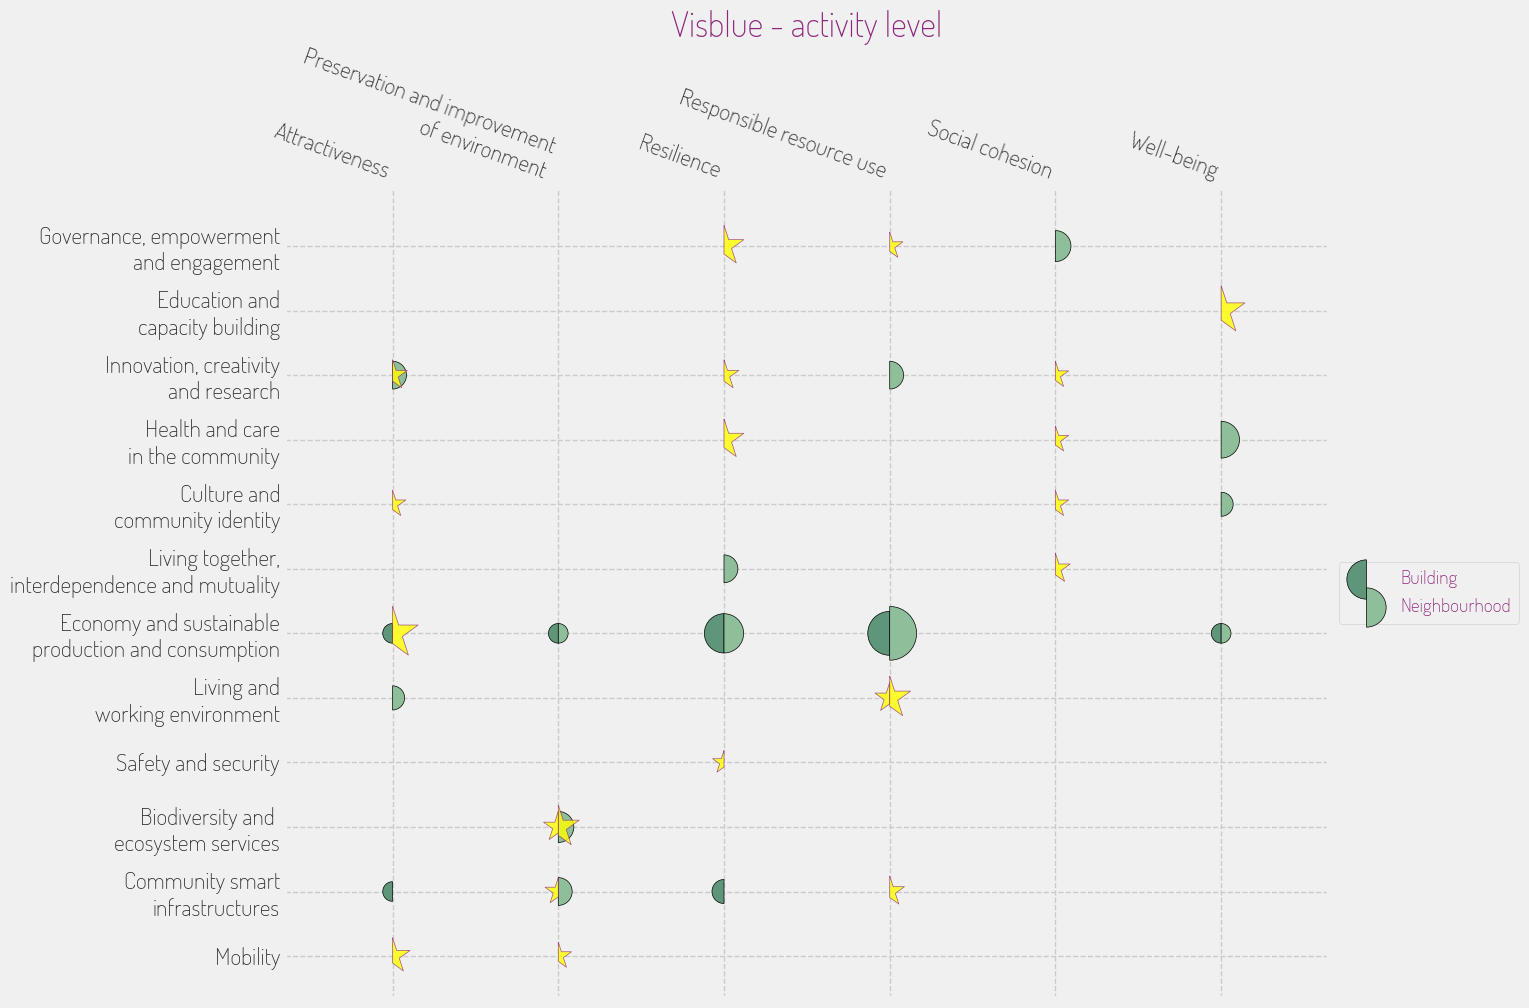

In [44]:
visblueactivities = df[(df.Source.str.lower().str.contains("visblue") ) & (df.Type == "Activities") & (df.Place.str.lower().str.contains("aar"))]
visbluevision = df[(df.Origin.str.lower().str.contains("clement") ) & (df.Type == "Vision")  & (df.Place.str.lower().str.contains("aar"))]
createExcel(visblueactivities,"doc/outputs/clement/visblue_activities.xlsx","Visblue activities.","AAR","All")
createExcel(visblueactivities,"doc/outputs/clement/visblue_vision.xlsx","Visblue vision.","AAR","All")

plt, ax = iImg.createImg(visblueactivities,visbluevision,title="Visblue - activity level")
plt.savefig("doc/outputs/clement/visblue_20250913.png", bbox_inches='tight')

## b. LL


/home/kelu/projets/pbn_37k/venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/home/kelu/projets/pbn_37k/venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/home/kelu/projets/pbn_37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/pbn_37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')


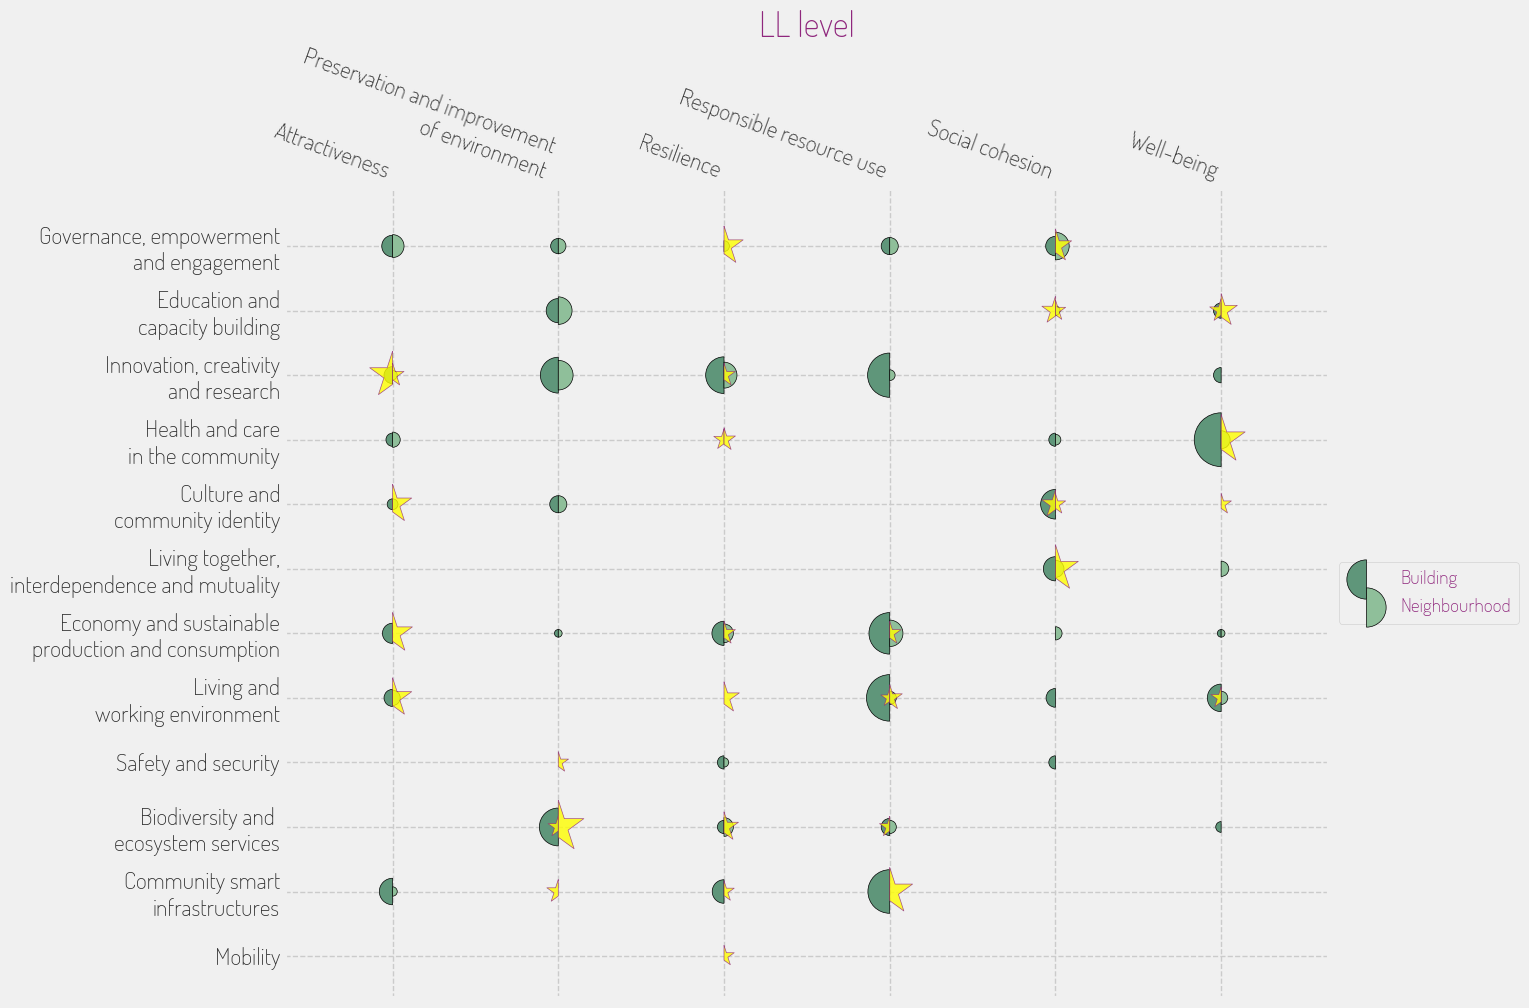

In [67]:
ll_activities = df[(df.Type == "Activities") & (df.Place.str.lower().str.contains("aar"))]
ll_vision = df[(df.Type == "Vision")  & (df.Place.str.lower().str.contains("aar"))]
ll_vision = ll_vision[~ll_vision["Origin"].str.contains("clement", case=False, na=False)]
ll_vision = ll_vision[~ll_vision["Source"].str.contains("visblue", case=False, na=False)]
ll_activities = ll_activities[~ll_activities["Origin"].str.contains("clement", case=False, na=False)]

createExcel(ll_activities,"doc/outputs/clement/ll_activities.xlsx","LL activities.","AAR","All")
createExcel(ll_vision,"doc/outputs/clement/ll_vision.xlsx","LL vision.","AAR","All")

plt, ax = iImg.createImg(ll_activities,ll_vision,title="LL level")
plt.savefig("doc/outputs/clement/ll_20250913.png", bbox_inches='tight')

## c. GBN

/home/kelu/projets/pbn_37k/venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/home/kelu/projets/pbn_37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/pbn_37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')


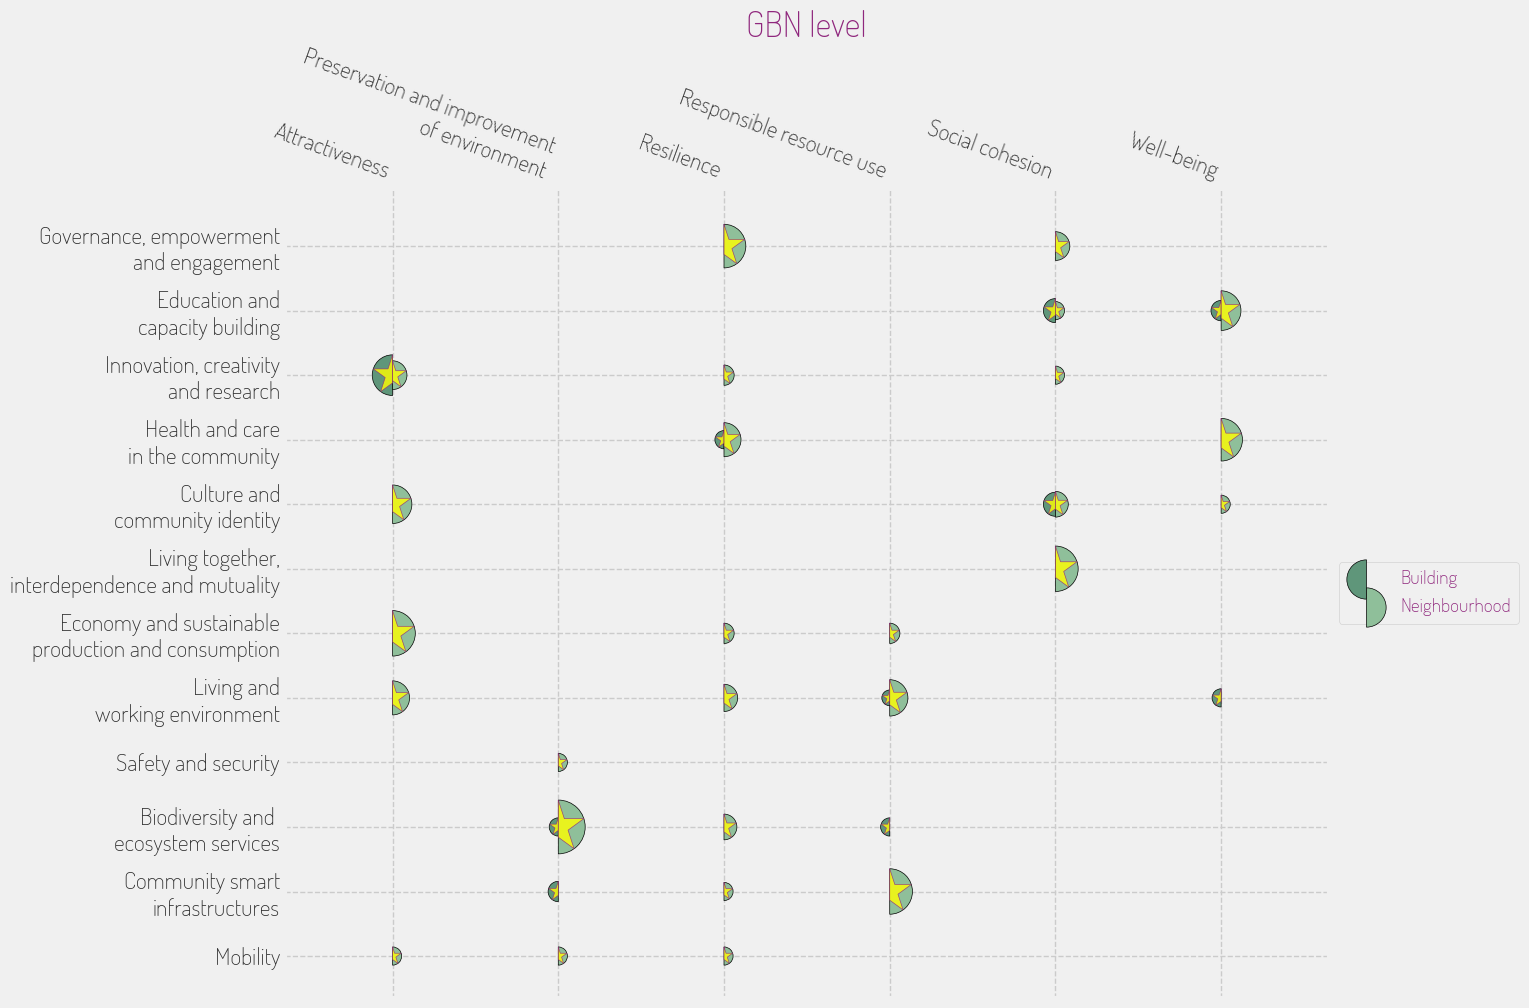

In [66]:
gbn_vision = df[(df.Type == "Vision")  & (df.Place.str.lower().str.contains("aar"))]
gbn_vision = gbn_vision[~gbn_vision["Source"].str.contains("visblue", case=False, na=False)]

createExcel(ll_vision,"doc/outputs/clement/gbn_vision.xlsx","LL vision.","AAR","All")

plt, ax = iImg.createImg(gbn_vision,gbn_vision,title="GBN level")
plt.savefig("doc/outputs/clement/gbn_20250913.png", bbox_inches='tight')